# **Unidad 7 Simulación Estocástica Computacional**

**Objetivos de la sesión**
- Entender qué es la simulación y por qué se usa.
- Conocer dos herramientas fundamentales: **Método de Monte Carlo** y **Procesos Estocásticos**.
- Implementar ejemplos prácticos en Python: *caminata aleatoria* y *simulación Monte Carlo*.


## **¿Qué es simular?**

En términos formales, simular es construir un modelo computacional que reproduzca el comportamiento de un sistema real incorporando incertidumbre mediante distribuciones de probabilidad.

**Ley de los Grandes Números aplicada a Monte Carlo**  
Si $X$ es una variable de interés y generamos $N$ réplicas independientes $x_1, \dots, x_N$, el estimador del valor esperado es
$$
\mu \approx \frac{1}{N}\sum_{i=1}^{N} x_i.
$$

**Modelo dinámico simple: Caminata Aleatoria**  
Un proceso discreto en tiempo puede escribirse como
$$
X_n = X_{n-1} + Z_n,
$$
donde $Z_n$ es ruido (por ejemplo $Z_n\sim \mathcal{N}(0,\sigma^2)$).


> En términos sencillos, simular es reproducir o imitar el comportamiento de un sistema del mundo real a lo largo del tiempo, utilizando distribuciones de probabilidad para representar la incertidumbre y aleatoriedad naturales del fenómeno. Se recurre a la simulación porque experimentar directamente sobre sistemas reales (por ejemplo, saturar un servidor de producción o cambiar el diseño físico de un motor) suele ser demasiado costoso, lento o incluso peligroso.



```
# Veamos un ejemplo de caminata aleatoria
```



# **Configuración para usar sintaxis de R y Python en el mismo entorno**

In [1]:
# 1. Cargar la extensión rpy2 para habilitar R en el cuaderno
%load_ext rpy2.ipython

# 2. Ejemplo en Python
python_list = [1, 2, 3, 4, 5]
print("Variable creada en Python:", python_list)



Variable creada en Python: [1, 2, 3, 4, 5]
[1] "Media calculada en R: 3"


array(['Media calculada en R: 3'], dtype='<U23')

In [ ]:
# 3. Ejemplo en R interactuando con Python (usando %R como line magic)
# Pasamos la variable de Python a R con '-i python_list'
%R -i python_list print(paste("Media calculada en R:", mean(python_list)))

In [2]:
%%R
mean(c(1,3,4))

[1] 2.666667


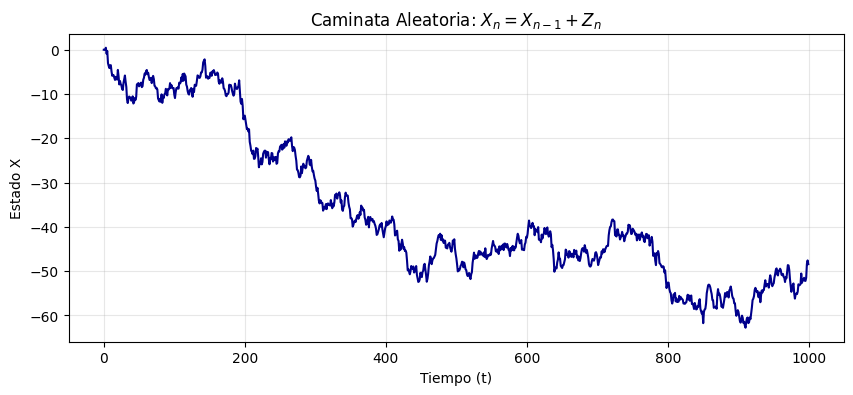

In [9]:
# Celda de código: Caminata aleatoria simple
import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(42)               # reproducibilidad
n_pasos = 1000
Z = np.random.normal(loc=0, scale=1, size=n_pasos)  # ruido blanco
X = np.zeros(n_pasos)
for t in range(1, n_pasos):
    X[t] = X[t-1] + Z[t]

plt.figure(figsize=(10,4))
plt.plot(X, color='darkblue')
plt.title('Caminata Aleatoria: $X_n = X_{n-1} + Z_n$')
plt.xlabel('Tiempo (t)')
plt.ylabel('Estado X')
plt.grid(alpha=0.3)
plt.show()


## Observación sobre varianza y estacionariedad

Si $Z_n$ tiene media cero y varianza constante $\sigma^2$, la varianza de $X_n$ crece con el tiempo. Para una caminata aleatoria simple con $X_0=0$:
$$
\mathrm{Var}(X_n) = n \sigma^2.
$$
Por tanto, el proceso **no es estacionario**: su varianza depende de $n$ y tiende a infinito conforme $n$ aumenta.


## **Buenas prácticas para experimentos estocásticos**

- **Fijar semilla** con `np.random.seed()` o `random.seed()` para reproducibilidad.  
- **Vectorizar** operaciones en Python con `numpy` para eficiencia cuando N es grande.  
- **Verificar supuestos**: si los datos observados muestran asimetría o cola larga, no uses una distribución sin justificarlo.  
- **Registrar metadatos**: semilla, versión de librerías, parámetros del experimento, y número de réplicas.


## Ejercicios prácticos demostrativos

Con ayuda de una AI generativa genera ejemplos para los siguientes casos, investiga y comenta los resultados.

1. **Distribuciones de llegada**  
   - Genera llegadas con un proceso de Poisson y compara la distribución de tiempos entre llegadas con una Exponencial. Simula la ocupación de un servidor simple (cola M/M/1) y estima la probabilidad de que la cola supere cierto umbral.

2. **Monte Carlo para [VaR](https://es.wikipedia.org/wiki/Valor_en_riesgo)**  
   - Simula 50,000 trayectorias de precios para un activo siguiendo un modelo de caminata geométrica y estima el [VaR](https://es.wikipedia.org/wiki/Valor_en_riesgo) al 95% para una cartera simple.

3. **Estabilidad de la caminata**  
   - Repite la caminata aleatoria con diferentes varianzas de $Z_n$ y grafica $\mathrm{Var}(X_n)$ estimada en función de $n$ para comprobar la relación lineal.


Puedes solicitar ayuda al asistente de la NotebookLM


### **Contextualización: Proceso de Poisson y tiempos entre llegadas**

**Breve introducción**  
- Este ejemplo simula la llegada de eventos (por ejemplo, peticiones a un servidor) que ocurren de forma aleatoria en el tiempo.  
- La idea práctica: modelar la secuencia de llegadas para estudiar carga, congestión o dimensionamiento de recursos sin afectar el sistema real.  
- En el código se generan los **tiempos entre llegadas** como variables aleatorias independientes con distribución Exponencial, y luego se acumulan para obtener los **tiempos de llegada**.


---

**Formalización mínima (notación y relaciones clave)**  
- Si las llegadas siguen un proceso de Poisson con tasa $\lambda$ (llegadas por unidad de tiempo), los tiempos entre llegadas $T_i$ son iid con distribución Exponencial:
$$
T_i \overset{\text{iid}}{\sim} \mathrm{Exp}(\lambda),\qquad f_{T}(t)=\lambda e^{-\lambda t},\; t\ge 0.
$$
- Los tiempos de llegada acumulados se obtienen por la suma:
$$
S_n = \sum_{i=1}^n T_i,
$$
y el número de llegadas en un intervalo $[0,t]$ cumple
$$
N(t)\sim \mathrm{Poisson}(\lambda t).
$$

---

**Puntos prácticos sobre el código**  
- `lambda_rate = 5.0` significa en promedio 5 llegadas por unidad de tiempo; el tiempo entre llegadas tiene media $1/\lambda = 0.2$ unidades.  
- `np.random.exponential(scale=1.0/lambda_rate, size=n_events)` genera los $T_i$.  
- `arrival_times = np.cumsum(inter_arrival)` construye la trayectoria temporal de eventos $S_n$.  
- La visualización de las primeras 200 llegadas permite inspeccionar la dispersión temporal; el histograma muestra la densidad empírica de los $T_i$ y debe aproximar la curva exponencial si el modelo es adecuado.

---

**Supuestos y comprobaciones**  
- **Independencia**: los $T_i$ se asumen independientes.  
- **Estacionariedad de la tasa**: $\lambda$ es constante en el tiempo; si la tasa varía (picos horarios), usar un proceso de Poisson no homogéneo $\lambda(t)$.  
- **Propiedad de falta de memoria**: la Exponencial cumple la propiedad de memoria sin memoria: para $s,t\ge0$, $\Pr(T> s+t\mid T>s)=\Pr(T>t)$. Comprobar si los datos reales muestran esta propiedad.  
- **Validación**: comparar histograma real de interarribos con la densidad exponencial ajustada; usar QQ-plot y pruebas de bondad de ajuste si procede.

---

**Interpretación**  
- Con este simulador se puede estimar métricas como la ocupación media de un servidor, la probabilidad de cola larga o el tiempo medio de espera en modelos de colas (p. ej. M/M/1).  
- Actividad sugerida: variar $\lambda$ y observar cómo cambian la densidad de interarribos y la tasa de eventos por unidad de tiempo; comparar un Poisson homogéneo con un Poisson no homogéneo que modele picos de tráfico.

---





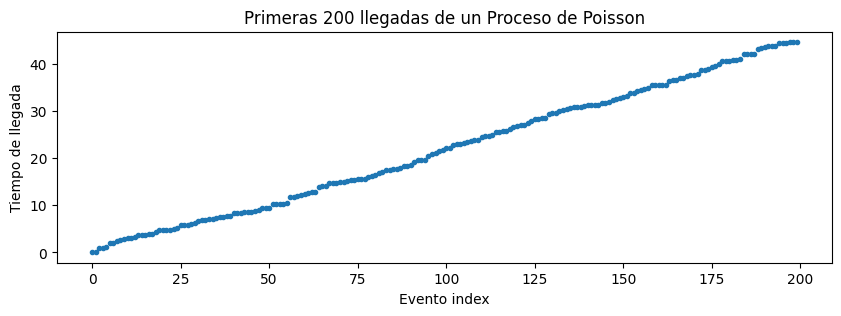

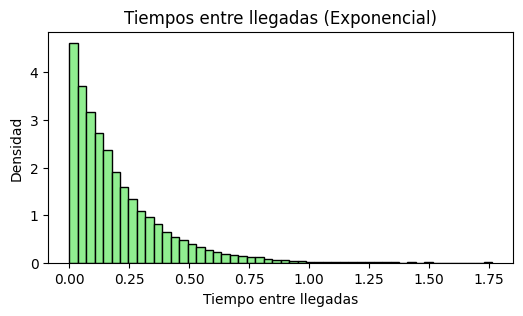

In [11]:
# Celda de código: Proceso de Poisson y tiempos entre llegadas exponenciales
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)
lambda_rate = 5.0   # llegadas por unidad de tiempo
n_events = 10000

# tiempos entre llegadas ~ Exponencial(1/lambda)
inter_arrival = np.random.exponential(scale=1.0/lambda_rate, size=n_events)
arrival_times = np.cumsum(inter_arrival)

plt.figure(figsize=(10,3))
plt.plot(arrival_times[:200], marker='o', linestyle='none', markersize=3)
plt.title('Primeras 200 llegadas de un Proceso de Poisson')
plt.xlabel('Evento index')
plt.ylabel('Tiempo de llegada')
plt.show()

# Histograma de tiempos entre llegadas
plt.figure(figsize=(6,3))
plt.hist(inter_arrival, bins=50, color='lightgreen', edgecolor='black', density=True)
plt.title('Tiempos entre llegadas (Exponencial)')
plt.xlabel('Tiempo entre llegadas')
plt.ylabel('Densidad')
plt.show()


### **Técnicas de simulación — Resumen sintetizado**

**Propósito**  
- Elegir la técnica adecuada para replicar un sistema según si interesa una **distribución estática** o la **evolución temporal** del sistema.

**Clasificación esencial**  
- **Estático vs Dinámico**:  
  - *Estático*: interesa la distribución de una salida bajo incertidumbre en las entradas (ej. Monte Carlo).  
  - *Dinámico*: interesa la trayectoria en el tiempo y la interacción de eventos.  
- **Determinista vs Estocástico**:  
  - *Determinista*: mismas entradas → misma salida.  
  - *Estocástico*: incorpora variables aleatorias; requiere réplicas.  
- **Continuo vs Discreto**:  
  - *Continuo*: estado cambia de forma ininterrumpida.  
  - *Discreto*: cambios en instantes puntuales por eventos.

**Criterio práctico de elección**  
- Si la pregunta es “¿cuál es la distribución de esta métrica dada la incertidumbre en las entradas?” → **Monte Carlo**.  
- Si la pregunta es “¿cómo evoluciona el sistema en el tiempo y cómo interactúan eventos?” → **Simulación por eventos discretos (DES)**.  


### Monte Carlo — Idea y formalización

**Idea**  
Generar muchas réplicas aleatorias de las entradas y evaluar la función de interés para estimar expectativas, percentiles o probabilidades.

**Formalización**  
Sea $X$ la variable de interés y $f(X)$ la cantidad que queremos estimar. Con $N$ réplicas independientes:
$$
\hat\mu = \frac{1}{N}\sum_{i=1}^N f(x_i).
$$
La Ley de los Grandes Números garantiza que $\hat\mu \xrightarrow{p} \mathbb{E}[f(X)]$ cuando $N\to\infty$.

**Estimador de una probabilidad**  
Para el evento $E=\{f(X)>c\}$:
$$
\hat p = \frac{1}{N}\sum_{i=1}^N \mathbf{1}\{f(x_i)>c\},
\qquad
\mathrm{SE}(\hat p)\approx\sqrt{\frac{\hat p(1-\hat p)}{N}}.
$$


### Simulación de tiempos secuenciales con Distribución Triangular

**Contexto**  
Modelamos el tiempo total de una operación secuencial que pasa por componentes A, B y C. Para cada componente usamos una distribución triangular con parámetros (mínimo, modo, máximo).

**Modelo**  
Si $T_A, T_B, T_C$ son tiempos independientes,
$$
T_{\text{total}} = T_A + T_B + T_C.
$$
Estimamos estadísticas de $T_{\text{total}}$ por Monte Carlo y percentiles (p. ej. percentil 95) para respaldar decisiones de SLA.


#### **Acuerdo de Nivel de Servicio (SLA)**

Un SLA es un acuerdo entre proveedor y cliente que define métricas cuantificables (por ejemplo, disponibilidad \(A\), tiempo de respuesta \(T_r\)), responsabilidades, procedimientos de medición y remedios por incumplimiento.  
Disponibilidad: $$A=\frac{\text{Tiempo activo}}{\text{Tiempo total}}$$  
Condición de cumplimiento típica: $$A \ge A_{\text{min}}$$

Componentes: descripción del servicio; métricas y objetivos; responsabilidades; medición y reporte; remedios/penalizaciones.


p_exceed = 0.0097, SE = 0.00031


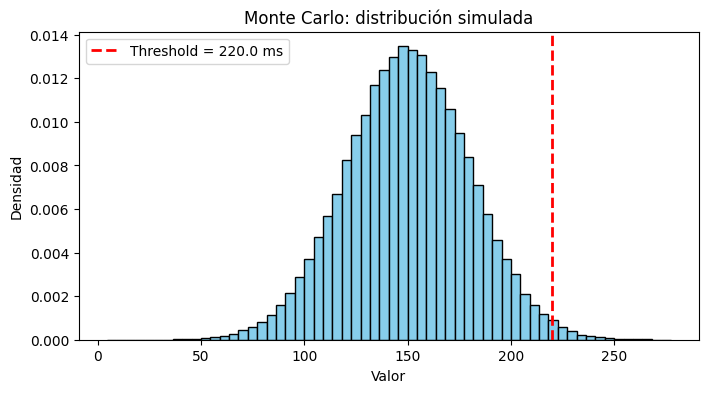

In [14]:
# Monte Carlo: estimar probabilidad de exceder un umbral
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)            # reproducibilidad
N = 100_000                  # número de réplicas
mu, sigma = 150.0, 30.0      # parámetros del modelo (ejemplo)

# Generar N latencias bajo la hipótesis Normal
X = np.random.normal(loc=mu, scale=sigma, size=N)

# Estimar probabilidad de exceder 220 ms y su error estándar
threshold = 220.0
p_exceed = np.mean(X > threshold)
se_p = np.sqrt(p_exceed * (1 - p_exceed) / N)

print(f"p_exceed = {p_exceed:.4f}, SE = {se_p:.5f}")

# Visualización rápida
plt.figure(figsize=(8,4))
plt.hist(X, bins=60, density=True, color='skyblue', edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold} ms')
plt.title('Monte Carlo: distribución simulada')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.show()


# **Técnicas algorítmicas de simulación**

En el contexto del modelado computacional, las "Técnicas de simulación" se refieren a los métodos algorítmicos que nos permiten procesar información y predecir respuestas de un sistema real frente a ciertos inputs, sin tener que intervenir el sistema físico.

Propósito: transformar teoría probabilística en procedimientos computacionales reproducibles que permitan estimar expectativas, probabilidades, trayectorias temporales o incertidumbres.

**Familias algorítmicas clave:**

+ Monte Carlo (MC): muestreo masivo para estimar integrales, medias y percentiles.

+ Cadenas de Markov y MDP: modelado de estados y transiciones; útil para sistemas con memoria limitada (propiedad de Markov) y para optimización secuencial.

+ Remuestreo (Bootstrap / Jackknife): generar réplicas de la muestra empírica para estimar variabilidad sin asumir una forma paramétrica.

> **Cuándo usar cada una:** MC para incertidumbre en entradas; Markov/MDP para dinámica de estados; remuestreo cuando los datos son escasos o las suposiciones paramétricas son dudosas.

**Monte Carlo (estimador de esperanza)**  
Sea $Y=f(X)$. Con $N$ réplicas independientes:
$$
\hat\mu = \frac{1}{N}\sum_{i=1}^N f(x_i),\qquad \mathrm{Var}(\hat\mu)\approx\frac{\sigma_f^2}{N}.
$$

**Cadena de Markov (matriz de transición)**  
Si el espacio de estados es $\mathcal{S}=\{1,\dots,m\}$ y $P=[p_{ij}]$ es la matriz de transición,
$$
p_{ij}=\Pr(S_{t+1}=j\mid S_t=i),\qquad \sum_{j=1}^m p_{ij}=1\ \forall i.
$$

**MDP (recompensa descontada)**  
La recompensa acumulada descontada:
$$
R_T=\sum_{k=0}^{\infty}\gamma^k r_{t+k+1},\quad 0\le\gamma<1,
$$
y la ecuación de Bellman para el valor óptimo:
$$
V(s)=\max_a\big(R(s,a)+\gamma \mathbb{E}[V(s')\mid s,a]\big).
$$



In [15]:
# Bootstrap: estimar distribución de la media a partir de una muestra pequeña
import numpy as np
np.random.seed(2026)

data = np.array([45,52,48,55,49,60,47,51,50,53])  # latencias (ms)
B = 2000  # réplicas bootstrap
means = np.empty(B)
n = len(data)

for b in range(B):
    sample = np.random.choice(data, size=n, replace=True)
    means[b] = sample.mean()

# Resultados
mean_est = means.mean()
ci_lower, ci_upper = np.percentile(means, [2.5, 97.5])
print(f"Media bootstrap: {mean_est:.2f} ms, IC95%: [{ci_lower:.2f}, {ci_upper:.2f}]")


Media bootstrap: 51.02 ms, IC95%: [48.70, 53.70]


In [16]:
# Simulación de una cadena de Markov con matriz de transición
import numpy as np
np.random.seed(3)

states = ["Operativo", "Caido"]
P = np.array([[0.95, 0.05],
              [0.60, 0.40]])  # filas suman 1
n_steps = 100
history = [0]  # 0 -> Operativo, 1 -> Caido

for _ in range(n_steps):
    current = history[-1]
    next_state = np.random.choice([0,1], p=P[current])
    history.append(next_state)

prop_operativo = np.mean(np.array(history) == 0)
print(f"Fracción de tiempo operativo: {prop_operativo*100:.1f}%")


Fracción de tiempo operativo: 93.1%


In [17]:
# Monte Carlo: estimar probabilidad de exceder un umbral
import numpy as np
np.random.seed(0)

N = 100_000
mu, sigma = 150.0, 30.0
X = np.random.normal(loc=mu, scale=sigma, size=N)
threshold = 220.0

p_hat = np.mean(X > threshold)
se_p = np.sqrt(p_hat*(1-p_hat)/N)
print(f"p_hat = {p_hat:.4f}, SE = {se_p:.5f}")


p_hat = 0.0097, SE = 0.00031


# **Modelos básicos de simulación**

Un modelo de simulación consiste en un conjunto de suposiciones sobre el comportamiento de un sistema, expresadas mediante relaciones lógico-matemáticas entre las entidades que lo componen.


Existen cuatro "arquitecturas" o modelos básicos principales que dominan la simulación computacional:

1. Modelos Dinámicos de Eventos Discretos
2. Modelos Dinámicos Continuos
3. Modelos de Caminata Aleatoria
4. Modelos de Monte Carlo.

### ¿Qué modelo elegir y por qué?

- **Modelos Dinámicos de Eventos Discretos (DES)**  
  - Uso: cuando el sistema cambia solo en instantes puntuales por la ocurrencia de eventos (llegadas, servicios, fallas).  
  - Pregunta típica: "¿Cuál será la longitud de la cola y el tiempo de espera promedio si la tasa de llegadas aumenta un 20%?"

- **Modelos Dinámicos Continuos**  
  - Uso: cuando las variables cambian de forma continua en el tiempo y se modelan con EDO/EDP o procesos estocásticos continuos.  
  - Pregunta típica: "¿Cómo evoluciona la carga térmica de un servidor bajo un patrón de demanda continuo?"

- **Modelos de Caminata Aleatoria (Random Walks)**  
  - Uso: para estudiar trayectorias discretas en tiempo donde cada paso es una perturbación aleatoria.  
  - Pregunta típica: "¿Cómo se dispersa la variable de interés alrededor de su media a lo largo del tiempo?"

- **Modelos de Monte Carlo**  
  - Uso: cuando interesa la distribución de una función de entradas inciertas; técnica estática basada en muestreo masivo.  
  - Pregunta típica: "¿Cuál es la probabilidad de que el tiempo total del proyecto supere 120 días?"


### Formalización

**Monte Carlo (estimador de esperanza)**  
Sea $Y=f(X)$. Con $N$ réplicas independientes:
$$
\hat\mu = \frac{1}{N}\sum_{i=1}^N f(x_i),\qquad \mathrm{Var}(\hat\mu)\approx\frac{\sigma_f^2}{N}.
$$

**Caminata Aleatoria unidimensional**  
Si $Z_n\in\{+1,-1\}$ con $P(Z_n=1)=p$, entonces
$$
X_n = X_{n-1} + Z_n.
$$
Para $X_0=0$ y $p=0.5$, $\mathrm{Var}(X_n)=n\sigma^2$ (crece con $n$, no estacionario).

**Modelo continuo (ejemplo Lotka–Volterra)**  
Para poblaciones $x(t),y(t)$:
$$
\frac{dx}{dt}=\alpha x - \beta x y,\qquad
\frac{dy}{dt}=\gamma y - \delta x y.
$$

**DES (esquema conceptual)**  
- Reloj $t$, lista de eventos ordenada por tiempo.  
- Al procesar un evento: actualizar estado, registrar métricas, programar nuevos eventos.


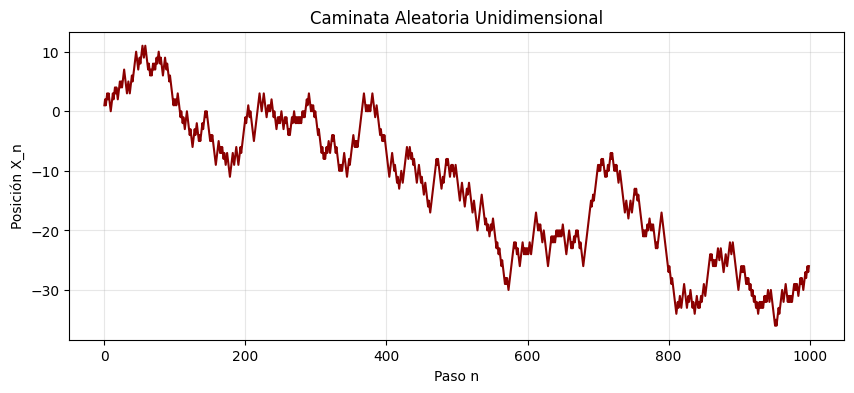

In [18]:
# Caminata aleatoria unidimensional
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2026)
n_pasos = 1000
p = 0.5
# pasos: +1 con prob p, -1 con prob 1-p
Z = np.where(np.random.rand(n_pasos) <= p, 1, -1)
X = np.cumsum(Z)  # X_n = sum_{i=1}^n Z_i

plt.figure(figsize=(10,4))
plt.plot(X, color='darkred')
plt.title('Caminata Aleatoria Unidimensional')
plt.xlabel('Paso n')
plt.ylabel('Posición X_n')
plt.grid(alpha=0.3)
plt.show()


Tiempo promedio: 90.02 (unidades)
Percentil 95: 117.12 (unidades)


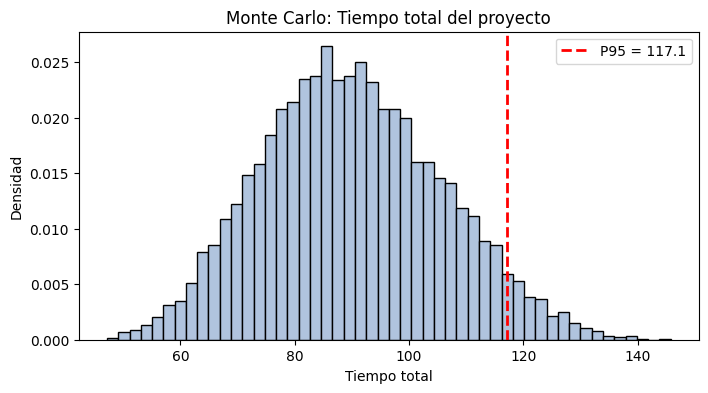

In [19]:
# Monte Carlo: tiempo total de proyecto con distribuciones triangulares
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 10000

# Parámetros (left, mode, right) para cada tarea
A = np.random.triangular(left=10, mode=25, right=50, size=N)
B = np.random.triangular(left=20, mode=40, right=80, size=N)
C = np.random.triangular(left=5,  mode=10, right=30, size=N)

T_total = A + B + C
mean_T = T_total.mean()
p95 = np.percentile(T_total, 95)

print(f"Tiempo promedio: {mean_T:.2f} (unidades)")
print(f"Percentil 95: {p95:.2f} (unidades)")

plt.figure(figsize=(8,4))
plt.hist(T_total, bins=50, density=True, color='lightsteelblue', edgecolor='black')
plt.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'P95 = {p95:.1f}')
plt.title('Monte Carlo: Tiempo total del proyecto')
plt.xlabel('Tiempo total')
plt.ylabel('Densidad')
plt.legend()
plt.show()


 Es fundamental comprender que una simulación computacional no produce valores "exactos" o deterministas sobre el desempeño de un sistema, sino que cada ejecución del modelo es, en realidad, un experimento estadístico que genera una muestra de observaciones aleatorias.  

Para extraer conclusiones válidas, debemos ejecutar la simulación múltiples veces (iteraciones o réplicas) y someter esa gran cantidad de datos a un procesamiento y análisis estadístico.

### 7.3 Procesamiento y Análisis Estadístico de Resultados

**Objetivo:** transformar salidas $Y_1,\dots,Y_N$ en estimadores robustos y cuantificar su incertidumbre.  

**Pasos clave:**
1) estimación puntual;
2) error estándar e intervalos de confianza;
3) detectar y eliminar burn‑in;
4) corregir autocorrelación (batch means o replicaciones independientes);
5) validar con bootstrap.


**Estimador de la media**
$$
\bar{Y}=\frac{1}{N}\sum_{i=1}^N Y_i.
$$

**Intervalo de confianza (aprox. Normal)**
$$
I.C.=\bar{Y}\pm Z_{\alpha/2}\frac{S}{\sqrt{N}},
$$
donde $S$ es la desviación estándar muestral.

**Proporción / probabilidad**
$$
\hat p=\frac{1}{N}\sum_{i=1}^N \mathbf{1}\{Y_i>c\},\qquad \mathrm{SE}(\hat p)\approx\sqrt{\frac{\hat p(1-\hat p)}{N}}.
$$


In [22]:
# IC y bootstrap para una salida de simulación
import numpy as np
from scipy import stats

np.random.seed(42)
Y = np.random.gamma(shape=2, scale=20, size=5000)  # ejemplo de salidas

# Estimador y IC 95%
N = len(Y)
mean = Y.mean()
s = Y.std(ddof=1)
se = s / np.sqrt(N)
z = stats.norm.ppf(0.975)
ic = (mean - z*se, mean + z*se)

# Bootstrap IC para la media (percentil)
B = 2000
boots = np.empty(B)
for b in range(B):
    sample = np.random.choice(Y, size=N, replace=True)
    boots[b] = sample.mean()
ci_boot = np.percentile(boots, [2.5, 97.5])

print(f"Mean={mean:.3f}, IC95% normal={ic}, IC95% bootstrap={ci_boot}")


Mean=40.351, IC95% normal=(np.float64(39.56797420065295), np.float64(41.1336217819807)), IC95% bootstrap=[39.55941667 41.0949538 ]


**Burn‑in (periodo transitorio):** eliminar las observaciones iniciales que reflejan condiciones de arranque.  

**Batch means:** dividir una única corrida larga en $k$ bloques de tamaño $b$ y usar las medias de bloque $\bar{Y}_j$ para construir un IC robusto; para $k$ suficientemente grande las medias de bloque son aproximadamente independientes. (Ver heurísticas MSER y batch means para detectar truncación y elegir $b$).


In [23]:
# Batch means
def batch_means_ci(Y, k=30, alpha=0.05):
    n = len(Y)
    b = n // k
    means = np.array([Y[i*b:(i+1)*b].mean() for i in range(k)])
    mean_bar = means.mean()
    sb = means.std(ddof=1)
    t = stats.t.ppf(1-alpha/2, df=k-1)
    half_width = t * sb / np.sqrt(k)
    return mean_bar, (mean_bar-half_width, mean_bar+half_width)

mean_b, ic_b = batch_means_ci(Y, k=40)
print("Batch means mean:", mean_b, "IC:", ic_b)


Batch means mean: 40.350797991316824 IC: (np.float64(39.5354946660473), np.float64(41.16610131658635))


**Buenas prácticas:**  
- Reportar semilla, N, duración de corrida y si se usaron replicaciones independientes.

- Comparar ICs por replicación vs batch means; si difieren, investigar autocorrelación.

- Visualizar series, autocorrelograma y medias por bloque; usar MSER o heurísticas gráficas para elegir burn‑in y tamaño de batch.


### Teorema del Límite Central — Formalización breve

**Enunciado (versión clásica).**  
Sea $X_1,\dots,X_n$ una muestra de variables aleatorias independientes e idénticamente distribuidas con media $\mu$ y varianza finita $\sigma^2$. Defina la media muestral
$$
\bar X_n=\frac{1}{n}\sum_{i=1}^n X_i.
$$
Entonces, cuando $n\to\infty$,
$$
\frac{\bar X_n-\mu}{\sigma/\sqrt{n}}\xrightarrow{d}\mathcal{N}(0,1).
$$

**Consecuencias prácticas para simulación y estimación de parámetros.**  
- Para $n$ suficientemente grande, la distribución de $\bar X_n$ puede aproximarse por una Normal con media $\mu$ y varianza $\sigma^2/n$.  
- Intervalo de confianza aproximado al nivel $(1-\alpha)$:
$$
\mathrm{IC}=\bar X_n \pm z_{\alpha/2}\,\frac{S}{\sqrt{n}},
$$
donde $S$ es la desviación estándar muestral y $z_{\alpha/2}$ el cuantil normal.  
- **Regla de la raíz cuadrada:** $\mathrm{SE}(\bar X_n)=S/\sqrt{n}$; para reducir la SE a la mitad hay que multiplicar $n$ por $4$.

**Limitaciones y comprobaciones**  
- El TLC requiere varianza finita y, en la práctica, independencia (o dependencia débil).  
- Si la muestra es pequeña, o la distribución tiene colas pesadas o fuerte asimetría, validar la aproximación con simulación, QQ‑plots y/o usar bootstrap para IC empíricos.


Corriendo experimentos para Normal(μ=0,σ=1) ...
Corriendo experimentos para Exponencial(mean=1) ...
Corriendo experimentos para Pareto(alpha=1.8) ...


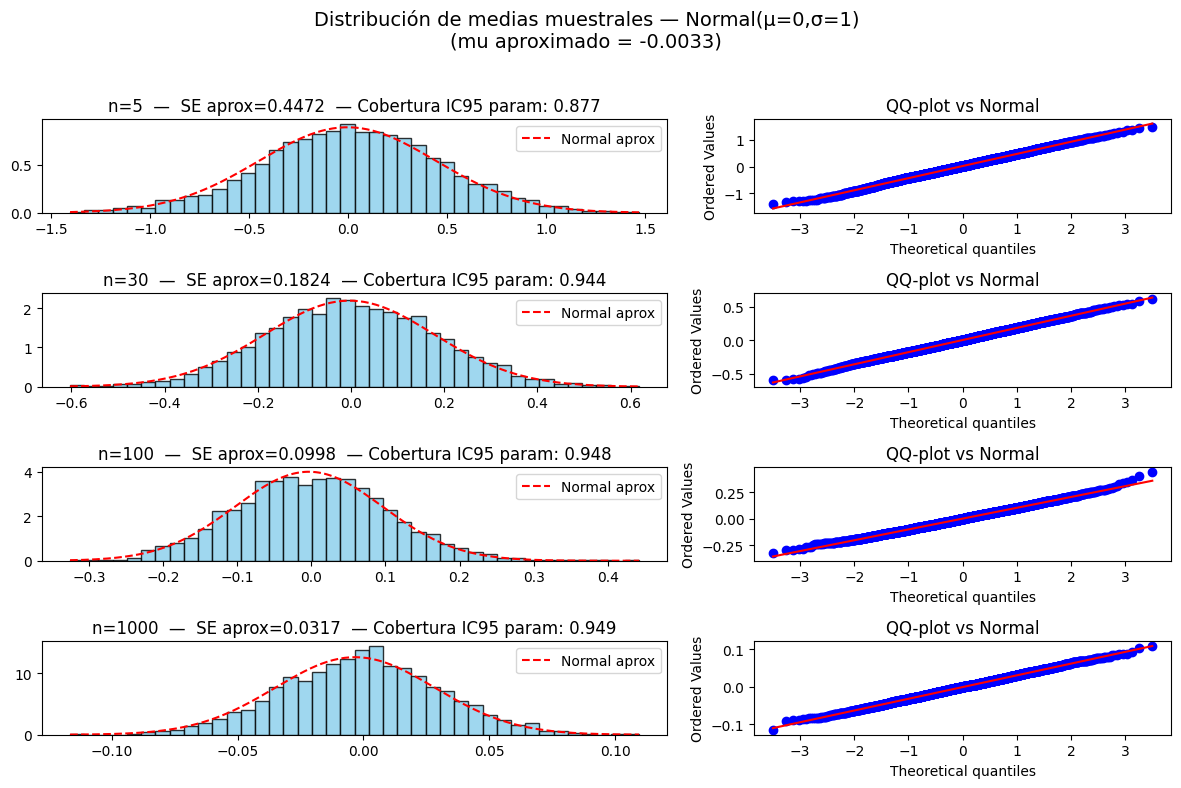

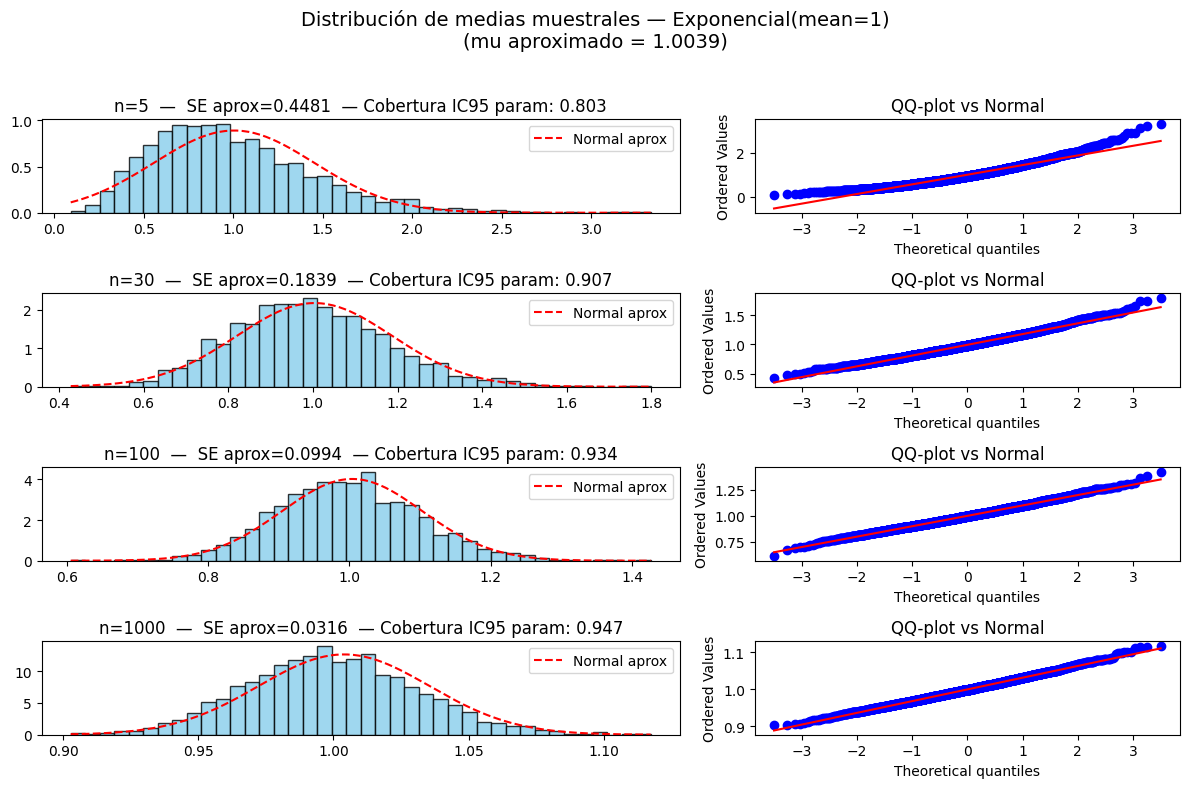

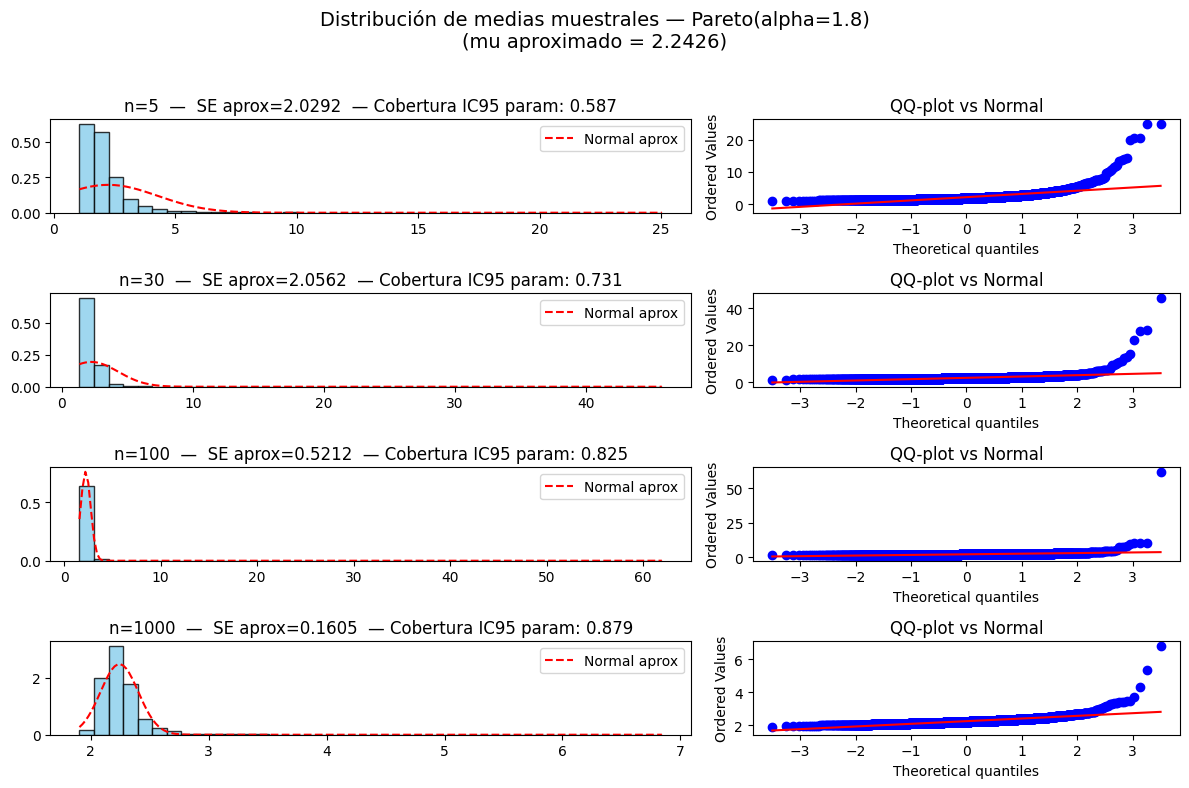


Ejemplo: comparación IC paramétrico vs bootstrap (Exponencial, n=30)
Media muestral: 1.0306
IC 95% paramétrico: [0.6073, 1.4539]
IC 95% bootstrap (percentil): [0.6435, 1.4670]


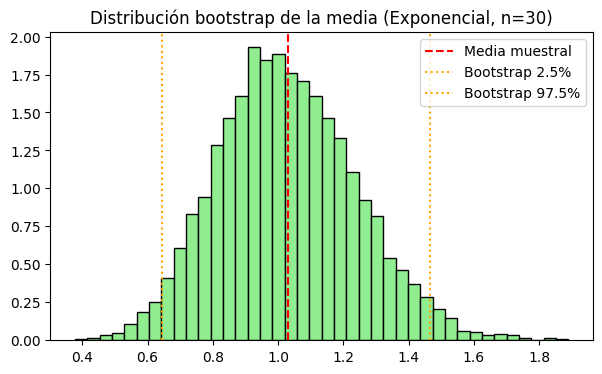


Demostración numérica: SE empírica para distintos n (Exponencial)
n= 25  SE_empírica ≈ 0.1997  (proporción respecto a n=25: 0.986)
n=100  SE_empírica ≈ 0.1009  (proporción respecto a n=25: 0.503)
n=400  SE_empírica ≈ 0.0503  (proporción respecto a n=25: 0.252)


In [35]:
# Simulación ilustrativa del Teorema del Límite Central
# - Compara la distribución de medias muestrales para distintas n y distribuciones
# - Evalúa cobertura empírica de IC 95% (paramétrico) y muestra bootstrap para caso asimétrico
# Ejecutar en Colab / Jupyter

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import trange

np.random.seed(2026)

def experiment(dist_sampler, dist_name, n_list=[5,30,100,1000], n_reps=5000):
    """
    dist_sampler(size) -> array: función que genera muestras de la distribución.
    n_list: lista de tamaños de muestra a comparar.
    n_reps: número de réplicas para estimar la distribución de la media.
    """
    results = {}
    for n in n_list:
        means = np.empty(n_reps)
        ci_covered = 0
        se_list = np.empty(n_reps)
        for r in range(n_reps):
            x = dist_sampler(n)
            means[r] = x.mean()
            s = x.std(ddof=1)
            se = s / np.sqrt(n)
            se_list[r] = se
            z95 = stats.norm.ppf(0.975)
            ci_low, ci_high = means[r] - z95*se, means[r] + z95*se
            # true mean depends on distribution; we approximate by large sample if unknown
            # For known distributions we can pass true_mean externally; here we estimate via many draws
            # We'll compute coverage later using a high-precision estimate of mu
        # estimate true mean by large sample draw (only once per distribution)
        mu_hat = dist_sampler(200000).mean()
        # recompute coverage properly
        covered = 0
        for r in range(n_reps):
            # reconstruct sample to compute its se and mean (cheap: reuse means and se_list)
            m = means[r]
            se = se_list[r]
            z95 = stats.norm.ppf(0.975)
            if (m - z95*se) <= mu_hat <= (m + z95*se):
                covered += 1
        coverage = covered / n_reps
        results[n] = {'means': means, 'se_mean': se_list.mean(), 'coverage95': coverage, 'mu_hat': mu_hat}
    return results

# Definir generadores para tres casos representativos
samplers = {
    'Normal(μ=0,σ=1)': lambda size: np.random.normal(loc=0.0, scale=1.0, size=size),
    'Exponencial(mean=1)': lambda size: np.random.exponential(scale=1.0, size=size),
    'Pareto(alpha=1.8)': lambda size: (np.random.pareto(a=1.8, size=size) + 1.0)  # heavy-tail
}

n_list = [5, 30, 100, 1000]
n_reps = 3000  # reducir si es necesario por tiempo

# Ejecutar experimentos (puede tardar unos segundos)
all_results = {}
for name, sampler in samplers.items():
    print(f"Corriendo experimentos para {name} ...")
    all_results[name] = experiment(sampler, name, n_list=n_list, n_reps=n_reps)

# Visualizaciones: histogramas de medias y QQ-plots para cada n y distribución
import matplotlib.gridspec as gridspec

for name in samplers.keys():
    res = all_results[name]
    mu_hat = res[n_list[-1]]['mu_hat']
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(len(n_list), 2, width_ratios=[3,2])
    fig.suptitle(f"Distribución de medias muestrales — {name}\n(mu aproximado = {mu_hat:.4f})", fontsize=14)
    for i, n in enumerate(n_list):
        means = res[n]['means']
        ax_hist = fig.add_subplot(gs[i,0])
        ax_qq = fig.add_subplot(gs[i,1])
        ax_hist.hist(means, bins=40, density=True, color='skyblue', edgecolor='black', alpha=0.8)
        # superponer Normal teórica con media mu_hat y var sigma^2/n (estimamos sigma por var de la población)
        # aproximamos sigma by std of large sample
        pop_std = samplers[name](200000).std(ddof=1)
        x_vals = np.linspace(means.min(), means.max(), 200)
        ax_hist.plot(x_vals, stats.norm.pdf(x_vals, loc=mu_hat, scale=pop_std/np.sqrt(n)), 'r--', lw=1.5, label='Normal aprox')
        ax_hist.set_title(f"n={n}  —  SE aprox={pop_std/np.sqrt(n):.4f}  — Cobertura IC95 param: {res[n]['coverage95']:.3f}")
        ax_hist.legend()
        # QQ-plot
        stats.probplot(means, dist="norm", plot=ax_qq)
        ax_qq.set_title("QQ-plot vs Normal")
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

# Ejemplo práctico: estimación de la media y comparación IC paramétrico vs bootstrap (caso asimétrico)
print("\nEjemplo: comparación IC paramétrico vs bootstrap (Exponencial, n=30)")
np.random.seed(2026)
n = 30
Y = np.random.exponential(scale=1.0, size=n)
mean_y = Y.mean()
s = Y.std(ddof=1)
se = s / np.sqrt(n)
z95 = stats.norm.ppf(0.975)
ic_param = (mean_y - z95*se, mean_y + z95*se)

# Bootstrap percentil para la media
B = 5000
boots = np.empty(B)
for b in range(B):
    sample = np.random.choice(Y, size=n, replace=True)
    boots[b] = sample.mean()
ci_boot = np.percentile(boots, [2.5, 97.5])

print(f"Media muestral: {mean_y:.4f}")
print(f"IC 95% paramétrico: [{ic_param[0]:.4f}, {ic_param[1]:.4f}]")
print(f"IC 95% bootstrap (percentil): [{ci_boot[0]:.4f}, {ci_boot[1]:.4f}]")

# Mostrar histograma bootstrap
plt.figure(figsize=(7,4))
plt.hist(boots, bins=40, density=True, color='lightgreen', edgecolor='black')
plt.axvline(mean_y, color='red', linestyle='--', label='Media muestral')
plt.axvline(ci_boot[0], color='orange', linestyle=':', label='Bootstrap 2.5%')
plt.axvline(ci_boot[1], color='orange', linestyle=':', label='Bootstrap 97.5%')
plt.title('Distribución bootstrap de la media (Exponencial, n=30)')
plt.legend()
plt.show()

# Demostración de la regla de la raíz cuadrada: SE escala ~ 1/sqrt(n)
print("\nDemostración numérica: SE empírica para distintos n (Exponencial)")
np.random.seed(2026)
n_values = [25, 100, 400]
for n in n_values:
    se_emp = np.std([np.random.exponential(scale=1.0, size=n).mean() for _ in range(2000)], ddof=1)
    print(f"n={n:3d}  SE_empírica ≈ {se_emp:.4f}  (proporción respecto a n=25: {se_emp / (np.std([np.random.exponential(scale=1.0, size=25).mean() for _ in range(2000)], ddof=1)):.3f})")


### 7.4 Experimentación en simulación — Propósito y principios

**Propósito**  
- Diseñar y ejecutar experimentos con el simulador para comparar configuraciones, estimar efectos de factores y cuantificar incertidumbre de forma reproducible.

**Principios básicos del diseño experimental aplicado a simulación**  
- **Aleatorización:** asignar aleatoriamente réplicas y semillas para evitar sesgos sistemáticos.  
- **Repetición (réplicas):** ejecutar múltiples réplicas por escenario para estimar la variabilidad intrínseca.  
- **Bloqueo:** agrupar corridas que comparten una fuente de variación conocida (p. ej., máquina, hora) para reducir ruido residual.  
- **Control de factores:** definir claramente factores, niveles y métricas de respuesta antes de ejecutar experimentos.


### Formalización estadística (comparación de tratamientos)

Si comparamos $k$ configuraciones (tratamientos) y ejecutamos $r$ réplicas por tratamiento, el modelo aditivo es:
$$
Y_{ij} = \mu + \tau_i + \varepsilon_{ij},\qquad i=1,\dots,k,\; j=1,\dots,r,
$$
donde $\varepsilon_{ij}\sim N(0,\sigma^2)$ representa la variabilidad estocástica de la simulación.

Hipótesis nula para ANOVA one‑way:
$$
H_0:\ \mu_1=\mu_2=\dots=\mu_k.
$$

Si $p$‑valor $<\alpha$ rechazamos $H_0$ y concluimos que al menos una configuración difiere.


### **Formalización del experimento factorial 2×2 y guía de interpretación **

**Contexto**  
Tienes un diseño factorial $2\times2$ con factores `Carga` (niveles $a_1,a_2$) y `Hilos` (niveles $b_1,b_2$), $r$ réplicas por escenario y salida observada $Y_{ijk}$ (réplica $k$ del escenario $(i,j)$). El objetivo es separar efectos principales e interacción y evaluar si las diferencias son estadísticamente relevantes.

---

**Significado simple de Carga y Hilos**

**Carga**

Qué es: un parámetro que representa la intensidad de trabajo o demanda que recibe el sistema.


Ejemplo concreto: Carga = 0.8 puede significar 80% de la carga nominal; Carga = 1.2 significa 120% (más tráfico o peticiones).

Por qué importa en el experimento: al aumentar la carga normalmente aumentan tiempos de respuesta, colas y uso de recursos; comparar niveles de carga te permite ver cómo escala el sistema.

**Hilos**

Qué es: número de threads o trabajadores concurrentes que ejecutan tareas en el sistema. En simulación de servidores, representa cuántos procesos/threads atienden peticiones en paralelo.

Ejemplo concreto: Hilos = 50 significa 50 trabajadores; Hilos = 100 significa 100 trabajadores.

Por qué importa en el experimento: más hilos pueden aumentar la concurrencia y throughput, pero también generar más contención por recursos (CPU, I/O), afectando latencias.

**Cómo interpretarlos juntos (en el diseño 2×2)**


- Cada combinación (Carga, Hilos) es un escenario o tratamiento. Por ejemplo: (0.8, 50), (0.8, 100), (1.2, 50), (1.2, 100).


- Efecto principal de Carga: cómo cambia la salida promedio (p. ej. latencia) al pasar de 0.8 a 1.2, promediando sobre niveles de Hilos.

- Efecto principal de Hilos: cómo cambia la salida al pasar de 50 a 100, promediando sobre niveles de Carga.

- Interacción: si el efecto de aumentar la carga depende de cuántos hilos hay (por ejemplo, aumentar carga empeora mucho cuando hay pocos hilos pero no cuando hay muchos), entonces hay interacción entre factores.

**Analogía rápida para recordar**

* Carga = cuánta gente entra al restaurante.

* Hilos = cuántos camareros tienes para atender.

La variable dependiente (Y) sería, por ejemplo, el tiempo que tarda cada cliente en ser atendido.

---

#### Modelo lineal aditivo con interacción
Sea $i\in\{1,2\}$ el nivel de `Carga`, $j\in\{1,2\}$ el nivel de `Hilos` y $k\in\{1,\dots,r\}$ la réplica. El modelo es
$$
Y_{ijk}=\mu+\alpha_i+\beta_j+(\alpha\beta)_{ij}+\varepsilon_{ijk},
$$
donde:

- $\mu$ es la media global.  
- $\alpha_i$ es el **efecto principal** del nivel $i$ de `Carga` (con restricción $\sum_i\alpha_i=0$).  
- $\beta_j$ es el **efecto principal** del nivel $j$ de `Hilos` (con $\sum_j\beta_j=0$).  
- $(\alpha\beta)_{ij}$ es el **efecto de interacción** entre `Carga` y `Hilos` (con restricciones de suma cero por filas/columnas).  
- $\varepsilon_{ijk}\overset{\text{iid}}{\sim}N(0,\sigma^2)$ es el término de error aleatorio.

---

#### Descomposición de la variabilidad (ANOVA)
La suma total de cuadrados se descompone en componentes:
$$
\mathrm{SST}=\mathrm{SSA}+\mathrm{SSB}+\mathrm{SSAB}+\mathrm{SSE},
$$
con grados de libertad correspondientes:
- $\mathrm{df}_{A}=a-1=1$,
- $\mathrm{df}_{B}=b-1=1$,
- $\mathrm{df}_{AB}=(a-1)(b-1)=1$,
- $\mathrm{df}_{E}=ab(r-1)=4(r-1)$,
- $\mathrm{df}_{T}=abr-1$.

Los cuadrados medios son
$$
\mathrm{MS}_X=\frac{\mathrm{SS}_X}{\mathrm{df}_X},
$$
y las estadísticas $F$ para probar efectos son
$$
F_A=\frac{\mathrm{MS}_A}{\mathrm{MS}_E},\qquad
F_B=\frac{\mathrm{MS}_B}{\mathrm{MS}_E},\qquad
F_{AB}=\frac{\mathrm{MS}_{AB}}{\mathrm{MS}_E}.
$$
Comparar cada $F$ con la $F$-distribución con $(\mathrm{df}_X,\mathrm{df}_E)$ grados de libertad para obtener $p$‑valores.

---

#### Interpretación práctica (orden lógico)
1. **Primero**: comprobar $H_0^{AB}:\ (\alpha\beta)_{ij}=0$ (no interacción).  
   - Si la interacción es significativa ($p_{AB}<\alpha$), **interpretar efectos principales con cautela**: los efectos de `Carga` dependen del nivel de `Hilos` y viceversa.  
   - Si la interacción no es significativa, proceder a interpretar efectos principales $\alpha_i$ y $\beta_j$ por separado.  
2. **Efectos principales**: si $F_A$ o $F_B$ son significativos, las medias marginales difieren entre niveles.  
3. **Comparaciones múltiples**: si hay más de 2 niveles por factor, aplicar post‑hoc (Tukey HSD) para identificar pares distintos; en 2×2 no es necesario, pero puedes reportar la diferencia de medias y su IC.

---

#### Tamaño del efecto y potencia
- **Eta cuadrado** (proporción de varianza explicada por un factor):
$$
\eta^2_X=\frac{\mathrm{SS}_X}{\mathrm{SST}}.
$$
- **Cohen's $f$** para ANOVA (relacionado con $\eta^2$):
$$
f=\sqrt{\frac{\eta^2}{1-\eta^2}}.
$$
Usar $f$ para cálculos de potencia y dimensionamiento muestral (herramientas: `statsmodels.stats.power` o tablas de potencia).

---

#### Supuestos y diagnósticos (qué verificar)
- **Independencia** de las réplicas (diseño y semillas aleatorias).  
- **Normalidad** de residuos: revisar QQ‑plot de residuos.  
- **Homoscedasticidad** (varianzas iguales): Levene o Bartlett; inspeccionar boxplots.  
- **Ausencia de valores influyentes**: residuales estandarizados y leverage.  
Si algún supuesto falla: considerar transformaciones (log), ANOVA robusta o análisis no paramétrico / bootstrap.

---

#### Entregables mínimos a reportar
- Tabla ANOVA con $\mathrm{SS}$, $\mathrm{df}$, $\mathrm{MS}$, $F$ y $p$‑valores.  
- Medias por escenario $(\bar Y_{11},\bar Y_{12},\bar Y_{21},\bar Y_{22})$ y medias marginales.  
- Tamaños de efecto ($\eta^2$) y IC para diferencias de medias.  
- Diagnósticos de supuestos (QQ‑plot, Levene, residuales vs ajuste).  
- Conclusión práctica: si hay interacción, describir cómo cambia el efecto de `Carga` según `Hilos`; si no, indicar qué factor(es) reducen o aumentan la salida $Y$.

---

#### Nota rápida de implementación (en tu notebook)
- Ya tienes el ajuste con `statsmodels`:
```python
model = smf.ols('Y ~ C(Carga) * C(Hilos)', data=df_exp).fit()


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     119.0
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           9.69e-19
Time:                        00:15:28   Log-Likelihood:                -147.45
No. Observations:                  40   AIC:                             302.9
Df Residuals:                      36   BIC:                             309.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

<Figure size 800x400 with 0 Axes>

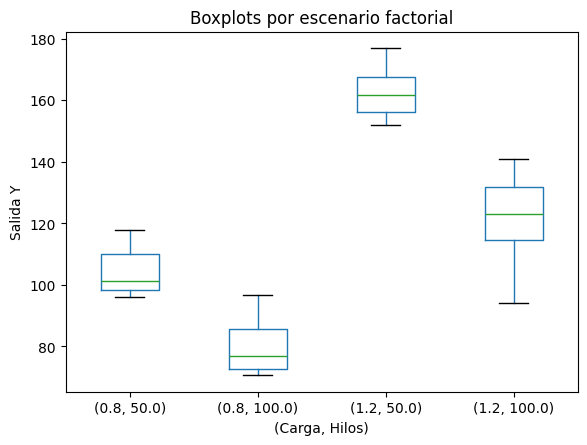

In [38]:
# Diseño factorial 2x2 (ejemplo) y ANOVA one-way para comparar tratamientos
import numpy as np
import pandas as pd
import itertools
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

np.random.seed(2026)

# Factores y niveles (ejemplo didáctico)
factors = {'Carga':[0.8, 1.2], 'Hilos':[50, 100]}
scenarios = list(itertools.product(*factors.values()))
df_scenarios = pd.DataFrame(scenarios, columns=factors.keys())

# Simulador toy: salida depende de factores + ruido
def sim_model(carga, hilos, seed=None):
    rng = np.random.RandomState(seed)
    base = 200.0
    y = base * carga / (1 + 0.01*hilos)
    noise = rng.normal(scale=8.0)
    return y + noise

reps = 10
rows = []
for i, row in df_scenarios.iterrows():
    for r in range(reps):
        y = sim_model(row['Carga'], row['Hilos'], seed=1000+i*reps+r)
        rows.append({'Carga': row['Carga'], 'Hilos': row['Hilos'], 'Y': y})

df_exp = pd.DataFrame(rows)

# Creamos versiones categóricas (como texto) explícitas en el DataFrame
# para no usar C() en la fórmula y evitar conflictos con la variable global 'C'
df_exp['Carga_cat'] = df_exp['Carga'].astype(str)
df_exp['Hilos_cat'] = df_exp['Hilos'].astype(str)

# ANOVA con interacción (factorial)
model = smf.ols('Y ~ Carga_cat * Hilos_cat', data=df_exp).fit()
print(model.summary())

# Visualización rápida
plt.figure(figsize=(8,4))
df_exp.boxplot(column='Y', by=['Carga','Hilos'], grid=False)
plt.suptitle('')
plt.title('Boxplots por escenario factorial')
plt.xlabel('(Carga, Hilos)')
plt.ylabel('Salida Y')
plt.show()


In [39]:
# Calcular los intervalos de confianza al 95% para los coeficientes del modelo
conf_interval = model.conf_int(alpha=0.05)
conf_interval.columns = ['2.5%', '97.5%']

print("Intervalos de Confianza (95%) para los coeficientes:")
display(conf_interval)


Intervalos de Confianza (95%) para los coeficientes:


,2.5%,97.5%
Intercept,72.904559,85.956297
Carga_cat[T.1.2],32.463146,50.921090
Hilos_cat[T.50.0],15.476631,33.934575
Carga_cat[T.1.2]:Hilos_cat[T.50.0],3.957004,30.060479


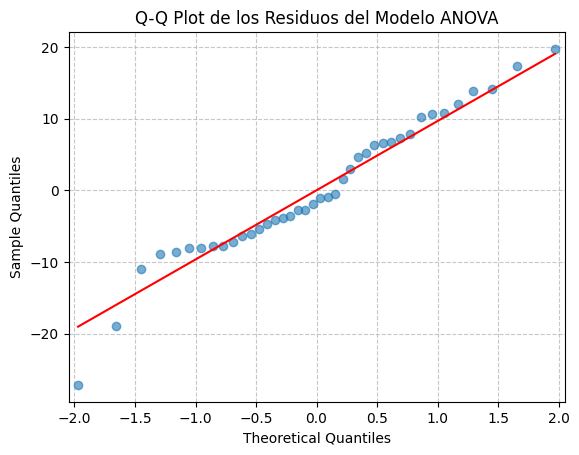

In [40]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generar Q-Q plot de los residuos para verificar la normalidad
fig = sm.qqplot(model.resid, line='s', alpha=0.6)
plt.title('Q-Q Plot de los Residuos del Modelo ANOVA')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
